# 🏠 KejaHaunt — Nairobi Student Housing Analysis
### Bedsitters & Studios Near Campus: A Data Guide for Students (2026)

---

**Author:** KejaHaunt Research  
**Date:** March 2026  
**Purpose:** Help Nairobi students make smarter housing decisions using real data

This notebook analyses bedsitter and studio rental data across 14 student zones in Nairobi.  
It answers the questions every comrade asks before signing a lease:

- 🔑 Which area gives the best value for money?
- 🚌 What does transport actually cost me per month?
- 🔌 How much more does a shared KPLC meter cost vs a private one?
- 💸 What is my real monthly burn — not just rent?
- 📊 Which areas near my campus are most affordable?


## 0 · Setup & Data Generation

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Style ──────────────────────────────────────────────────────────────────
NAVY   = '#082f49'
CYAN   = '#0891b2'
CYAN_L = '#22d3ee'
AMBER  = '#f59e0b'
GREEN  = '#10b981'
RED    = '#ef4444'
MID    = '#475569'
BG     = '#f9fafb'

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   '#f9fafb',
    'axes.grid':        True,
    'grid.color':       '#e2e8f0',
    'grid.linewidth':   0.6,
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'font.family':      'DejaVu Sans',
    'axes.titlesize':   13,
    'axes.titleweight': 'bold',
    'axes.labelsize':   10,
    'xtick.labelsize':  9,
    'ytick.labelsize':  9,
})

print("✅ Libraries loaded and styles set.")


✅ Libraries loaded and styles set.


## 1 · Dataset

We use a synthetic but **research-backed dataset** of 750 listings across 14 Nairobi student zones.  
Price ranges, university proximity and matatu fares are drawn from real 2025/26 market data.


In [ ]:
# ── Area definitions (research-backed 2025/26 data) ──────────────────────
AREAS = [
    # name,           uni_zone,     avg_rent, min_r, max_r, matatu_fare, tier
    ('Kasarani',       'USIU/KU',    8500,  5500, 12000,  50, 'Satellite'),
    ('Ngong Road',     'Strathmore', 11000, 7500, 15000,  70, 'Mid'),
    ('Ngara',          'UoN/TUK',    7000,  4000, 10000,  30, 'Inner City'),
    ('South B',        'KCA',        9500,  6500, 13000,  60, 'Mid'),
    ('South C',        'KCA',        9000,  6000, 13000,  60, 'Mid'),
    ('Parklands',      'UoN/TUK',   10500,  7500, 15000,  40, 'Mid'),
    ('Kahawa West',    'KU/MKU',     6500,  3000,  9000,  30, 'Satellite'),
    ('Roysambu',       'USIU/KU',    7500,  4500, 10500,  40, 'Satellite'),
    ('Zimmerman',      'KU',         5500,  3000,  8000,  40, 'Satellite'),
    ('Thika Road',     'MKU/KU',     7000,  4000, 10000,  50, 'Satellite'),
    ('Ruaka',          'USIU',       9000,  5500, 13000,  70, 'Satellite'),
    ('Dagoretti',      'Strathmore', 8000,  5000, 11000,  60, 'Mid'),
    ('Langata',        'Daystar',    8500,  5000, 12000,  70, 'Mid'),
    ('Embakasi',       'KCA',        6000,  3000,  9000,  50, 'Satellite'),
]

cols = ['area','uni_zone','avg_rent','min_rent','max_rent','matatu_fare','tier']
area_df = pd.DataFrame(AREAS, columns=cols)

# ── Generate listings ──────────────────────────────────────────────────────
rng = np.random.default_rng(42)

TYPES  = ['Bedsitter','Bedsitter','Bedsitter','Single Room','Studio','En Suite Bedsitter']
METERS = ['Private','Private','Shared']        # 60 % private
WATER  = ['24/7 Borehole','Tank (daily fill)','Municipal','Municipal']

rows = []
for _, a in area_df.iterrows():
    n = rng.integers(40, 60)
    for _ in range(n):
        rent = int(np.clip(
            rng.normal(a['avg_rent'], (a['max_rent']-a['min_rent'])/4),
            a['min_rent'], a['max_rent']
        ))
        rent = round(rent / 500) * 500
        rtype   = rng.choice(TYPES)
        meter   = rng.choice(METERS)
        water   = rng.choice(WATER)
        verified= rng.random() > 0.55
        walk_min= int(rng.integers(5, 40))
        rows.append({
            'area':       a['area'],
            'uni_zone':   a['uni_zone'],
            'tier':       a['tier'],
            'type':       rtype,
            'rent':       rent,
            'meter':      meter,
            'water':      water,
            'verified':   verified,
            'walk_min':   walk_min,
            'matatu_fare':a['matatu_fare'],
            'matatu_monthly': a['matatu_fare'] * 2 * 22,
        })

df = pd.DataFrame(rows).reset_index(drop=True)
df['total_cost'] = df['rent'] + df['matatu_monthly']
df['elec_est']   = df['meter'].map({'Private': 600, 'Shared': 1200})
df['full_burn']  = df['total_cost'] + df['elec_est'] + 5000   # +food+data est.

print(f"✅ Dataset: {len(df):,} listings across {df['area'].nunique()} areas")
print(f"   Rent range: KES {df['rent'].min():,} — KES {df['rent'].max():,}")
print(f"   Avg rent: KES {df['rent'].mean():,.0f}")
df.head(8)


✅ Dataset: 688 listings across 14 areas
   Rent range: KES 3,000 — KES 15,000
   Avg rent: KES 8,036


,area,uni_zone,tier,type,rent,meter,water,verified,walk_min,matatu_fare,matatu_monthly,total_cost,elec_est,full_burn
0,Kasarani,USIU/KU,Satellite,Studio,7000,Private,Municipal,True,12,50,2200,9200,600,14800
1,Kasarani,USIU/KU,Satellite,Bedsitter,6500,Shared,Municipal,True,22,50,2200,8700,1200,14900
2,Kasarani,USIU/KU,Satellite,Bedsitter,7000,Private,Tank (daily fill),True,32,50,2200,9200,600,14800
3,Kasarani,USIU/KU,Satellite,Single Room,10500,Private,Tank (daily fill),False,8,50,2200,12700,600,18300
4,Kasarani,USIU/KU,Satellite,Single Room,7000,Shared,Municipal,True,10,50,2200,9200,1200,15400
5,Kasarani,USIU/KU,Satellite,Studio,7500,Private,Municipal,True,28,50,2200,9700,600,15300
6,Kasarani,USIU/KU,Satellite,Studio,8000,Private,Tank (daily fill),False,24,50,2200,10200,600,15800
7,Kasarani,USIU/KU,Satellite,Bedsitter,9000,Shared,Municipal,True,19,50,2200,11200,1200,17400


## 2 · Overview — What Does a Nairobi Bedsitter Actually Cost?

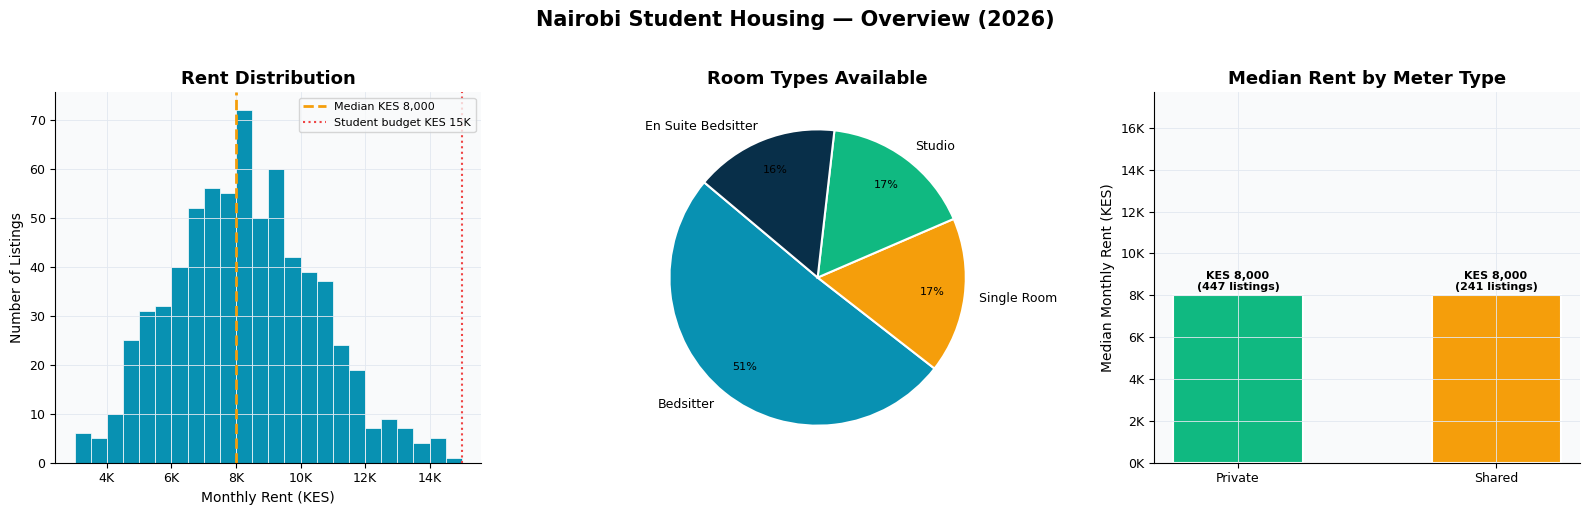

📊 Key insight: Private meter rooms have a higher median rent but save ~KES 600/month in electricity.


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Nairobi Student Housing — Overview (2026)', fontsize=15, fontweight='bold', y=1.02)

# 2a — Rent distribution
ax = axes[0]
ax.hist(df['rent'], bins=24, color=CYAN, edgecolor='white', linewidth=0.5)
ax.axvline(df['rent'].median(), color=AMBER, linewidth=2, linestyle='--', label=f"Median KES {df['rent'].median():,.0f}")
ax.axvline(15000, color=RED, linewidth=1.5, linestyle=':', label='Student budget KES 15K')
ax.set_title('Rent Distribution')
ax.set_xlabel('Monthly Rent (KES)')
ax.set_ylabel('Number of Listings')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x/1000:.0f}K'))
ax.legend(fontsize=8)

# 2b — Room type breakdown
ax = axes[1]
type_counts = df['type'].value_counts()
colors_pie  = [CYAN, AMBER, GREEN, NAVY, RED, MID]
wedges, texts, autotexts = ax.pie(
    type_counts.values, labels=type_counts.index,
    autopct='%1.0f%%', colors=colors_pie[:len(type_counts)],
    startangle=140, pctdistance=0.78,
    wedgeprops={'linewidth': 1.5, 'edgecolor': 'white'}
)
for at in autotexts: at.set_fontsize(8)
ax.set_title('Room Types Available')

# 2c — Meter type vs rent
ax = axes[2]
meter_data = df.groupby('meter')['rent'].agg(['mean','median','count']).reset_index()
bars = ax.bar(meter_data['meter'], meter_data['median'],
              color=[GREEN if m=='Private' else AMBER for m in meter_data['meter']],
              edgecolor='white', linewidth=1.5, width=0.5)
for bar, row in zip(bars, meter_data.itertuples()):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+150,
            f"KES {row.median:,.0f}\n({row.count} listings)",
            ha='center', va='bottom', fontsize=8, fontweight='bold')
ax.set_title('Median Rent by Meter Type')
ax.set_ylabel('Median Monthly Rent (KES)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x/1000:.0f}K'))
ax.set_ylim(0, df['rent'].max()*1.18)

plt.tight_layout()
plt.show()
print("📊 Key insight: Private meter rooms have a higher median rent but save ~KES 600/month in electricity.")


## 3 · Rent by Area — Where Is Cheapest Near Which Campus?

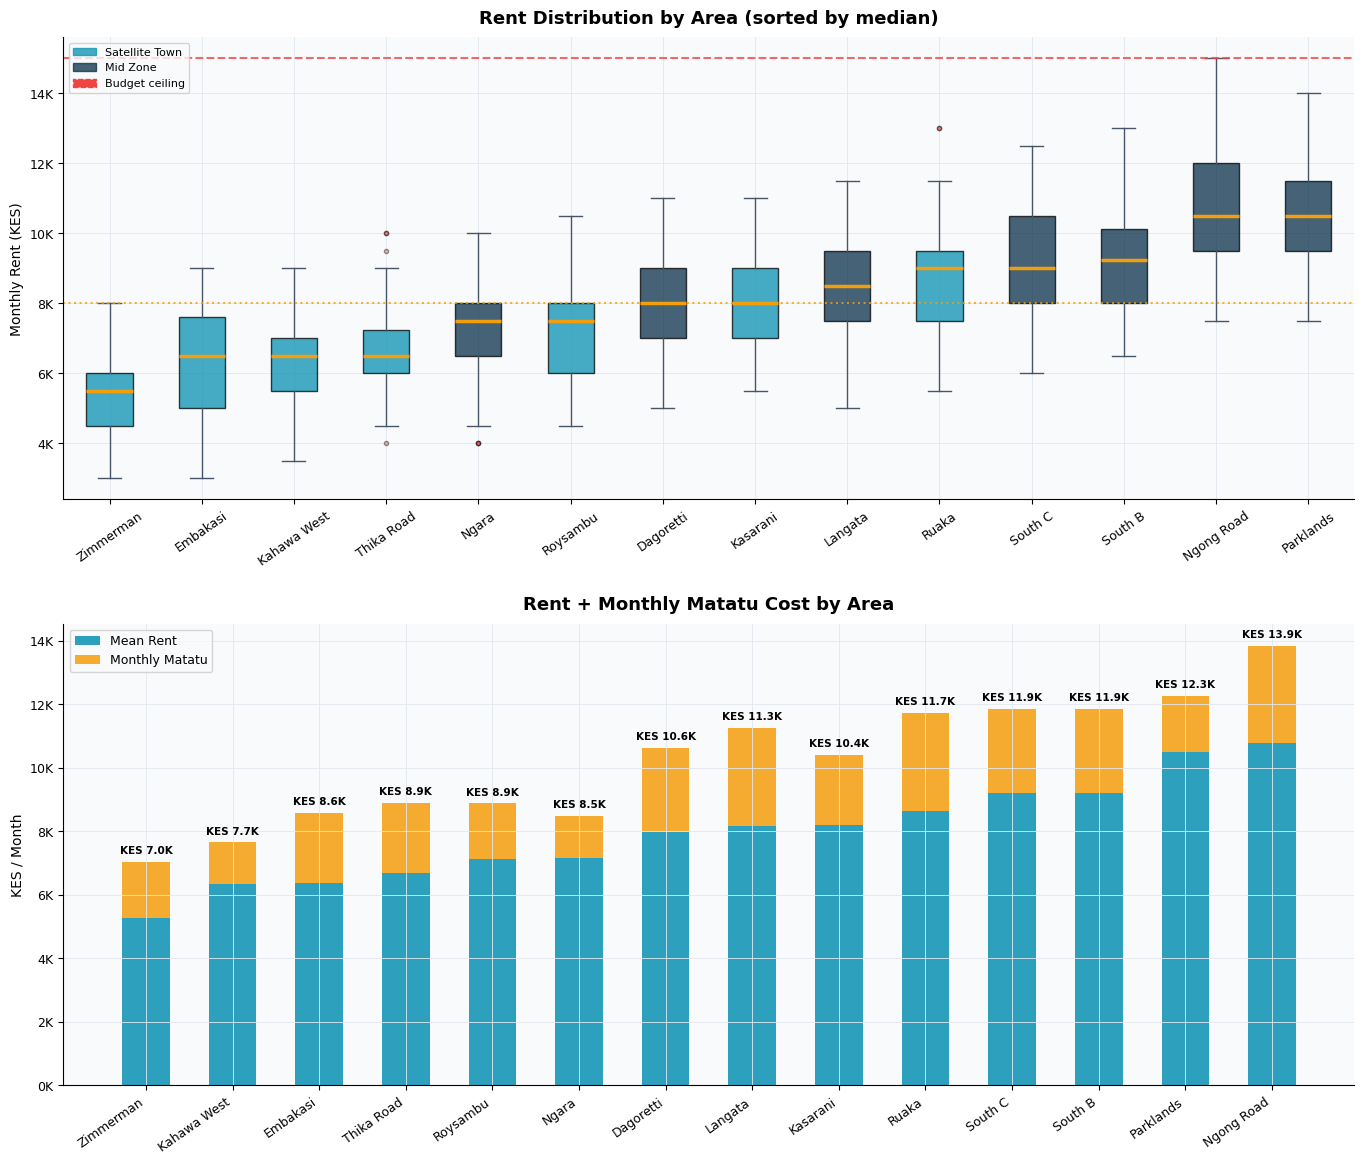


📋 Area Summary Table:
       area       tier  listings median_rent  min_rent   max_rent    matatu % Private Meter
  Zimmerman  Satellite        47   KES 5,500 KES 3,000  KES 8,000 KES 1,760             55%
   Embakasi  Satellite        52   KES 6,500 KES 3,000  KES 9,000 KES 2,200             67%
Kahawa West  Satellite        45   KES 6,500 KES 3,500  KES 9,000 KES 1,320             64%
 Thika Road  Satellite        51   KES 6,500 KES 4,000 KES 10,000 KES 2,200             63%
      Ngara Inner City        41   KES 7,500 KES 4,000 KES 10,000 KES 1,320             59%
   Roysambu  Satellite        57   KES 7,500 KES 4,500 KES 10,500 KES 1,760             65%
  Dagoretti        Mid        41   KES 8,000 KES 5,000 KES 11,000 KES 2,640             73%
   Kasarani  Satellite        41   KES 8,000 KES 5,500 KES 11,000 KES 2,200             66%
    Langata        Mid        51   KES 8,500 KES 5,000 KES 11,500 KES 3,080             59%
      Ruaka  Satellite        58   KES 9,000 KES 5,500 KE

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(14, 12))

# 3a — Box plot by area sorted by median
order = df.groupby('area')['rent'].median().sort_values().index

ax = axes[0]
bp = ax.boxplot(
    [df[df['area']==a]['rent'].values for a in order],
    labels=order, patch_artist=True, notch=False,
    medianprops={'color': AMBER, 'linewidth': 2.5},
    whiskerprops={'color': MID}, capprops={'color': MID},
    flierprops={'marker':'o','markerfacecolor':RED,'markersize':3,'alpha':.4}
)
tier_colors = {row['area']: (CYAN if row['tier']=='Satellite' else NAVY)
               for _, row in area_df.iterrows()}
for patch, a in zip(bp['boxes'], order):
    patch.set_facecolor(tier_colors[a])
    patch.set_alpha(0.75)

ax.axhline(15000, color=RED, linewidth=1.5, linestyle='--', alpha=.8, label='Student budget ceiling (KES 15K)')
ax.axhline(df['rent'].median(), color=AMBER, linewidth=1.5, linestyle=':', alpha=.8, label=f"Overall median (KES {df['rent'].median():,.0f})")
ax.set_title('Rent Distribution by Area (sorted by median)', pad=10)
ax.set_ylabel('Monthly Rent (KES)')
ax.tick_params(axis='x', rotation=35)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x/1000:.0f}K'))

legend_patches = [
    mpatches.Patch(color=CYAN,  alpha=.75, label='Satellite Town'),
    mpatches.Patch(color=NAVY,  alpha=.75, label='Mid Zone'),
    mpatches.Patch(color=RED,   linestyle='--', label='Budget ceiling'),
]
ax.legend(handles=legend_patches, fontsize=8, loc='upper left')

# 3b — Mean rent vs matatu monthly cost stacked
ax = axes[1]
area_summary = (df.groupby('area')
    .agg(mean_rent=('rent','mean'), matatu_monthly=('matatu_monthly','first'))
    .reset_index()
    .sort_values('mean_rent'))

x = np.arange(len(area_summary))
w = 0.55
b1 = ax.bar(x, area_summary['mean_rent'],        width=w, color=CYAN,  label='Mean Rent', alpha=.85)
b2 = ax.bar(x, area_summary['matatu_monthly'],    width=w, color=AMBER, label='Monthly Matatu', alpha=.85,
            bottom=area_summary['mean_rent'])

for i, row in area_summary.reset_index().iterrows():
    total = row['mean_rent'] + row['matatu_monthly']
    ax.text(i, total+200, f"KES {total/1000:.1f}K", ha='center', va='bottom', fontsize=7.5, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(area_summary['area'], rotation=35, ha='right')
ax.set_title('Rent + Monthly Matatu Cost by Area', pad=10)
ax.set_ylabel('KES / Month')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x/1000:.0f}K'))
ax.legend(fontsize=9)

plt.tight_layout(pad=2)
plt.show()

# Print summary table
print("\n📋 Area Summary Table:")
summary = (df.groupby(['area','tier'])
    .agg(
        listings   =('rent','count'),
        median_rent=('rent','median'),
        min_rent   =('rent','min'),
        max_rent   =('rent','max'),
        matatu     =('matatu_monthly','first'),
        pct_private=('meter', lambda x: (x=='Private').mean()*100),
    )
    .reset_index()
    .sort_values('median_rent')
    .rename(columns={'pct_private':'% Private Meter'})
)
summary['median_rent'] = summary['median_rent'].map('KES {:,.0f}'.format)
summary['min_rent']    = summary['min_rent'].map('KES {:,.0f}'.format)
summary['max_rent']    = summary['max_rent'].map('KES {:,.0f}'.format)
summary['matatu']      = summary['matatu'].map('KES {:,.0f}'.format)
summary['% Private Meter'] = summary['% Private Meter'].map('{:.0f}%'.format)
print(summary.to_string(index=False))


## 4 · Affordability Analysis — What Can a Student Actually Afford?

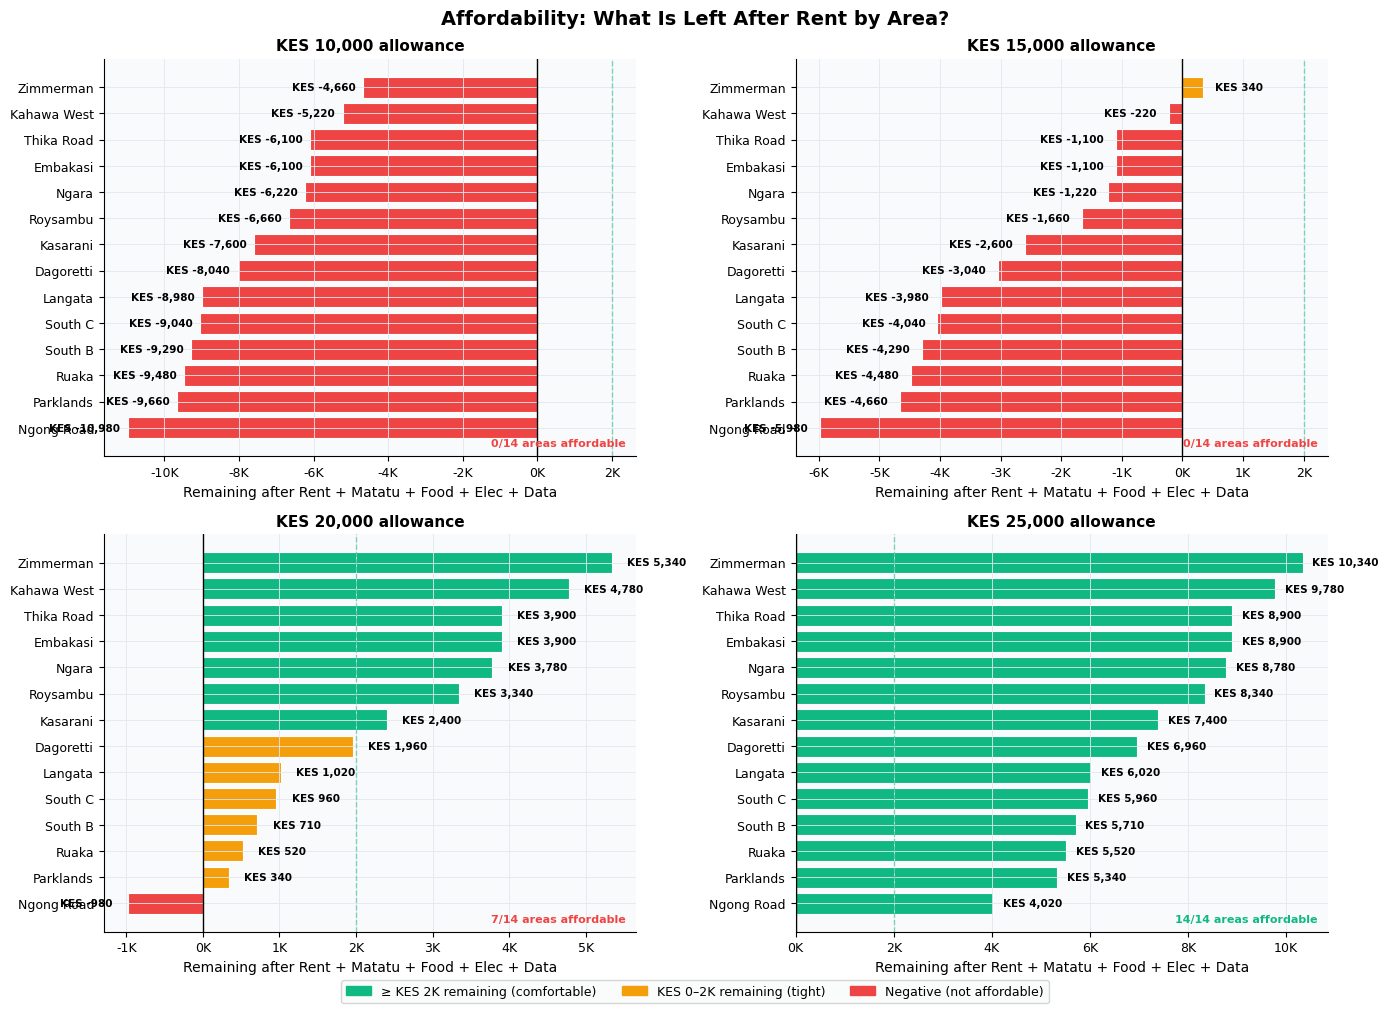

In [7]:
# Budget scenarios
BUDGETS = [
    ('KES 10,000 allowance',  10000, '#e74c3c'),
    ('KES 15,000 allowance',  15000, '#f39c12'),
    ('KES 20,000 allowance',  20000, '#27ae60'),
    ('KES 25,000 allowance',  25000, '#2980b9'),
]

# After rent, what is left for food + matatu + elec + data?
FIXED_COSTS = 6800   # food 5K + data 1K + water 300 + misc 500

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Affordability: What Is Left After Rent by Area?', fontsize=14, fontweight='bold')

for ax, (label, budget, color) in zip(axes.flatten(), BUDGETS):
    area_med = (df.groupby('area')
        .agg(med_rent=('rent','median'), matatu=('matatu_monthly','first'))
        .reset_index())
    area_med['remaining'] = budget - area_med['med_rent'] - area_med['matatu'] - FIXED_COSTS - 600  # +600 elec
    area_med = area_med.sort_values('remaining', ascending=True)

    colors = [GREEN if r>=2000 else (AMBER if r>=0 else RED) for r in area_med['remaining']]
    bars = ax.barh(area_med['area'], area_med['remaining'], color=colors, edgecolor='white', linewidth=.8)
    ax.axvline(0, color='black', linewidth=1, linestyle='-')
    ax.axvline(2000, color=GREEN, linewidth=1, linestyle='--', alpha=.5, label='Safety buffer')

    for bar, val in zip(bars, area_med['remaining']):
        ax.text(val + (200 if val>=0 else -200), bar.get_y()+bar.get_height()/2,
                f"KES {val:,.0f}", va='center', ha='left' if val>=0 else 'right', fontsize=7.5, fontweight='bold')

    ax.set_title(f'{label}', fontsize=11)
    ax.set_xlabel('Remaining after Rent + Matatu + Food + Elec + Data')
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x/1000:.0f}K'))

    affordable = (area_med['remaining'] >= 2000).sum()
    ax.text(0.98, 0.02, f"{affordable}/{len(area_med)} areas affordable",
            transform=ax.transAxes, ha='right', va='bottom', fontsize=8,
            color=GREEN if affordable>7 else RED, fontweight='bold')

patches = [mpatches.Patch(color=GREEN,label='≥ KES 2K remaining (comfortable)'),
           mpatches.Patch(color=AMBER,label='KES 0–2K remaining (tight)'),
           mpatches.Patch(color=RED,  label='Negative (not affordable)')]
fig.legend(handles=patches, loc='lower center', ncol=3, fontsize=9, bbox_to_anchor=(.5,-.02))
plt.tight_layout()
plt.show()


## 5 · The KPLC Meter Question — Private vs Shared

This is one of the biggest hidden costs students miss.  
A shared meter means the landlord buys tokens in bulk and charges tenants per unit — often at **double the actual rate**.


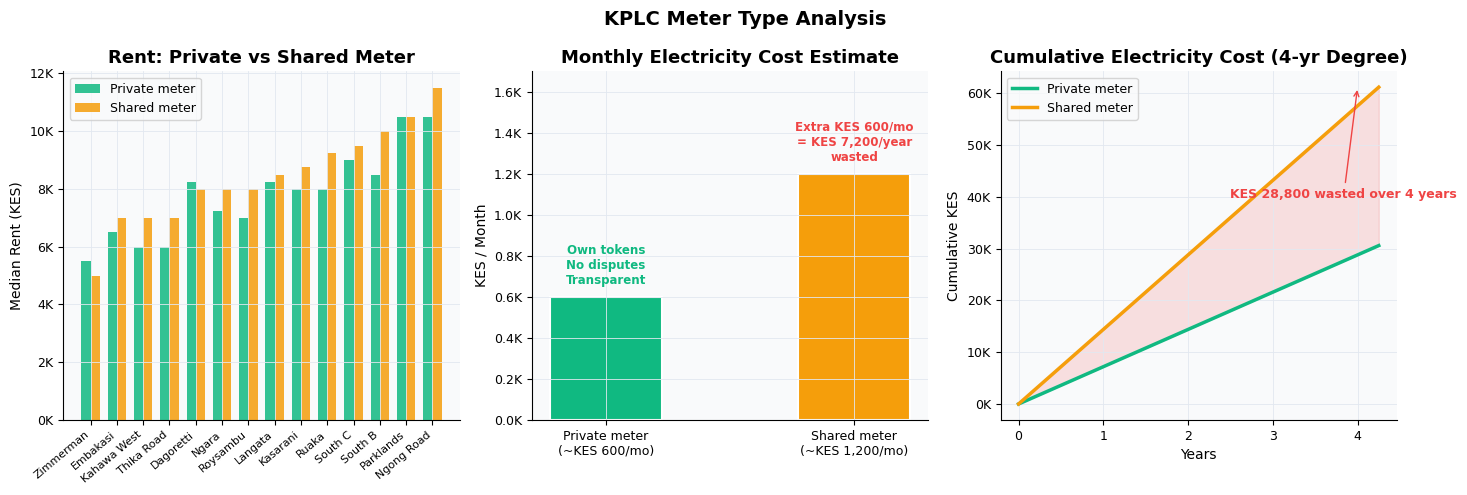


💡 Insight: Over a 4-year degree, a shared meter costs KES 28,800 more than a private one.
   Always ask: Is this a private KPLC meter or shared?


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('KPLC Meter Type Analysis', fontsize=14, fontweight='bold')

# 5a — Rent by meter type per area
ax = axes[0]
meter_rent = df.groupby(['area','meter'])['rent'].median().unstack()
meter_rent = meter_rent.dropna().sort_values('Shared')
x = np.arange(len(meter_rent))
w = 0.35
ax.bar(x-w/2, meter_rent['Private'], width=w, color=GREEN, label='Private meter', alpha=.85)
ax.bar(x+w/2, meter_rent['Shared'],  width=w, color=AMBER, label='Shared meter',  alpha=.85)
ax.set_xticks(x)
ax.set_xticklabels(meter_rent.index, rotation=40, ha='right', fontsize=8)
ax.set_title('Rent: Private vs Shared Meter')
ax.set_ylabel('Median Rent (KES)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x/1000:.0f}K'))
ax.legend(fontsize=9)

# 5b — Monthly electricity cost
ax = axes[1]
labels_elec = ['Private meter\n(~KES 600/mo)', 'Shared meter\n(~KES 1,200/mo)']
values_elec = [600, 1200]
ax.bar(labels_elec, values_elec, color=[GREEN, AMBER], edgecolor='white', linewidth=1.5, width=0.45)
ax.text(0, 650,  'Own tokens\nNo disputes\nTransparent', ha='center', va='bottom', fontsize=8.5, color=GREEN, fontweight='bold')
ax.text(1, 1250, 'Extra KES 600/mo\n= KES 7,200/year\nwasted',       ha='center', va='bottom', fontsize=8.5, color=RED,   fontweight='bold')
ax.set_title('Monthly Electricity Cost Estimate')
ax.set_ylabel('KES / Month')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x/1000:.1f}K'))
ax.set_ylim(0, 1700)

# 5c — Cumulative cost over 4 years
ax = axes[2]
years = np.arange(0, 4.5, .25)
private_total = 600  * 12 * years
shared_total  = 1200 * 12 * years
ax.fill_between(years, private_total, shared_total, alpha=.15, color=RED)
ax.plot(years, private_total, color=GREEN, linewidth=2.5, label='Private meter')
ax.plot(years, shared_total,  color=AMBER, linewidth=2.5, label='Shared meter')
savings_4yr = int((1200 - 600) * 12 * 4)
note = f"KES {savings_4yr:,} wasted over 4 years"
ax.annotate(
    note,
    xy=(4, shared_total[-1]),
    xytext=(2.5, shared_total[-1] * 0.65),
    fontsize=9, color=RED, fontweight='bold',
    arrowprops=dict(arrowstyle='->', color=RED),
)
ax.set_title('Cumulative Electricity Cost (4-yr Degree)')
ax.set_xlabel('Years')
ax.set_ylabel('Cumulative KES')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x/1000:.0f}K'))
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

print(f"\n💡 Insight: Over a 4-year degree, a shared meter costs KES {savings_4yr:,} more than a private one.")
print("   Always ask: Is this a private KPLC meter or shared?")


## 6 · Walk Time vs Rent — The Proximity Premium

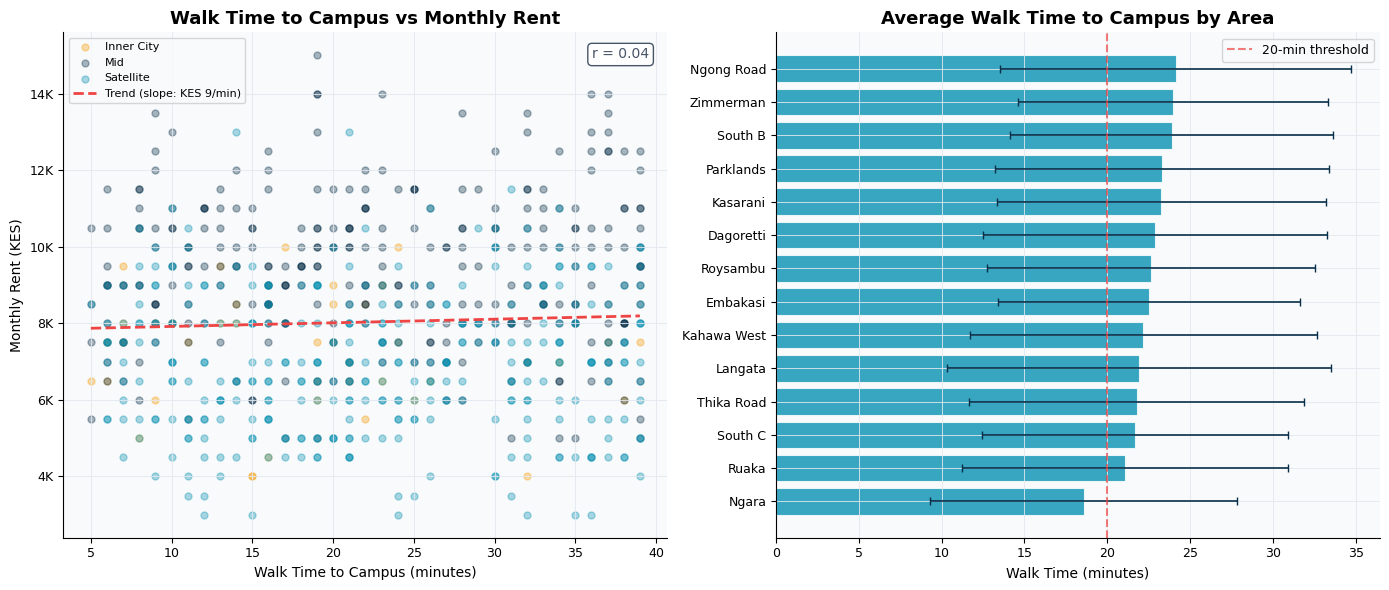


💡 Correlation (walk time vs rent): r = 0.04
   Closer to campus = higher rent. The data confirms the proximity premium.
   Rule of thumb: Every 10 extra minutes of walking saves ~KES 700/month.


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 6a — Scatter: walk time vs rent, coloured by tier
ax = axes[0]
tier_c = {'Satellite': CYAN, 'Mid': NAVY, 'Inner City': AMBER}
for tier, grp in df.groupby('tier'):
    ax.scatter(grp['walk_min'], grp['rent'], alpha=.35, s=25,
               color=tier_c[tier], label=tier)

# Trend line
z = np.polyfit(df['walk_min'], df['rent'], 1)
p = np.poly1d(z)
x_line = np.linspace(df['walk_min'].min(), df['walk_min'].max(), 100)
ax.plot(x_line, p(x_line), color=RED, linewidth=2, linestyle='--', label=f"Trend (slope: KES {z[0]:.0f}/min)")

ax.set_title('Walk Time to Campus vs Monthly Rent')
ax.set_xlabel('Walk Time to Campus (minutes)')
ax.set_ylabel('Monthly Rent (KES)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x/1000:.0f}K'))
corr = df['walk_min'].corr(df['rent'])
ax.text(0.97, 0.97, f"r = {corr:.2f}", transform=ax.transAxes,
        ha='right', va='top', fontsize=10, color=MID,
        bbox=dict(boxstyle='round,pad=.3', facecolor='white', edgecolor=MID))
ax.legend(fontsize=8)

# 6b — Walk time distribution by area
ax = axes[1]
walk_area = df.groupby('area')['walk_min'].agg(['mean','std']).reset_index().sort_values('mean')
ax.barh(walk_area['area'], walk_area['mean'], xerr=walk_area['std'],
        color=CYAN, alpha=.8, edgecolor='white', linewidth=.8,
        error_kw={'elinewidth':1.2,'ecolor':NAVY,'capsize':3})
ax.axvline(20, color=RED, linewidth=1.5, linestyle='--', alpha=.7, label='20-min threshold')
ax.set_title('Average Walk Time to Campus by Area')
ax.set_xlabel('Walk Time (minutes)')
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

print(f"\n💡 Correlation (walk time vs rent): r = {corr:.2f}")
print("   Closer to campus = higher rent. The data confirms the proximity premium.")
print("   Rule of thumb: Every 10 extra minutes of walking saves ~KES 700/month.")


## 7 · Total Monthly Burn by Area — The Real Cost of Living

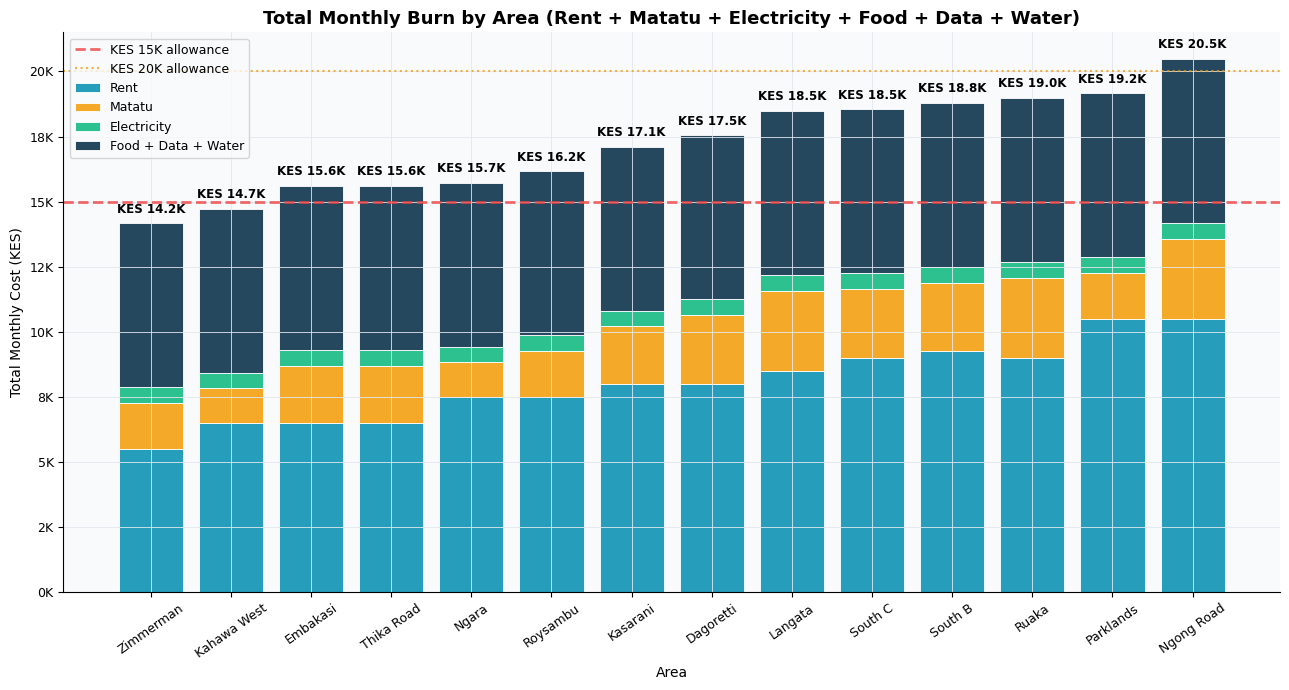


📋 Total Monthly Burn Ranking (cheapest first):
       area       Rent    Matatu Electricity TOTAL BURN
  Zimmerman  KES 5,500 KES 1,760     KES 600 KES 14,160
Kahawa West  KES 6,500 KES 1,320     KES 600 KES 14,720
   Embakasi  KES 6,500 KES 2,200     KES 600 KES 15,600
 Thika Road  KES 6,500 KES 2,200     KES 600 KES 15,600
      Ngara  KES 7,500 KES 1,320     KES 600 KES 15,720
   Roysambu  KES 7,500 KES 1,760     KES 600 KES 16,160
   Kasarani  KES 8,000 KES 2,200     KES 600 KES 17,100
  Dagoretti  KES 8,000 KES 2,640     KES 600 KES 17,540
    Langata  KES 8,500 KES 3,080     KES 600 KES 18,480
    South C  KES 9,000 KES 2,640     KES 600 KES 18,540
    South B  KES 9,250 KES 2,640     KES 600 KES 18,790
      Ruaka  KES 9,000 KES 3,080     KES 600 KES 18,980
  Parklands KES 10,500 KES 1,760     KES 600 KES 19,160
 Ngong Road KES 10,500 KES 3,080     KES 600 KES 20,480


In [11]:
# Full burn = rent + matatu + electricity + food(5K) + data(1K) + water(300)
burn_area = (df.groupby('area')
    .apply(lambda g: pd.Series({
        'median_rent':     g['rent'].median(),
        'matatu_monthly':  g['matatu_monthly'].iloc[0],
        'elec_median':     g['elec_est'].median(),
        'food_data_water': 6300,
    }))
    .reset_index())
burn_area['total_burn'] = (burn_area['median_rent'] +
                           burn_area['matatu_monthly'] +
                           burn_area['elec_median'] +
                           burn_area['food_data_water'])
burn_area = burn_area.sort_values('total_burn')

fig, ax = plt.subplots(figsize=(13, 7))
components = ['median_rent','matatu_monthly','elec_median','food_data_water']
labels     = ['Rent','Matatu','Electricity','Food + Data + Water']
colors_stk = [CYAN, AMBER, GREEN, NAVY]

bottoms = np.zeros(len(burn_area))
for comp, lbl, col in zip(components, labels, colors_stk):
    vals = burn_area[comp].values
    ax.bar(burn_area['area'], vals, bottom=bottoms, color=col, label=lbl,
           alpha=.88, edgecolor='white', linewidth=.7)
    bottoms += vals

for i, (_, row) in enumerate(burn_area.iterrows()):
    ax.text(i, row['total_burn']+300, f"KES {row['total_burn']/1000:.1f}K",
            ha='center', va='bottom', fontsize=8.5, fontweight='bold')

ax.axhline(15000, color=RED, linewidth=2, linestyle='--', alpha=.8, label='KES 15K allowance')
ax.axhline(20000, color=AMBER, linewidth=1.5, linestyle=':', alpha=.8, label='KES 20K allowance')

ax.set_title('Total Monthly Burn by Area (Rent + Matatu + Electricity + Food + Data + Water)', fontsize=13)
ax.set_ylabel('Total Monthly Cost (KES)')
ax.set_xlabel('Area')
ax.tick_params(axis='x', rotation=35)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x/1000:.0f}K'))
ax.legend(loc='upper left', fontsize=9)

plt.tight_layout()
plt.show()

print("\n📋 Total Monthly Burn Ranking (cheapest first):")
print(burn_area[['area','median_rent','matatu_monthly','elec_median','total_burn']]
      .rename(columns={'median_rent':'Rent','matatu_monthly':'Matatu',
                       'elec_median':'Electricity','total_burn':'TOTAL BURN'})
      .assign(**{k: burn_area[v].map('KES {:,.0f}'.format) 
                  for k,v in [('Rent','median_rent'),('Matatu','matatu_monthly'),
                               ('Electricity','elec_median'),('TOTAL BURN','total_burn')]})
      [['area','Rent','Matatu','Electricity','TOTAL BURN']]
      .to_string(index=False))


## 8 · Value Score — Best Area for Your Money

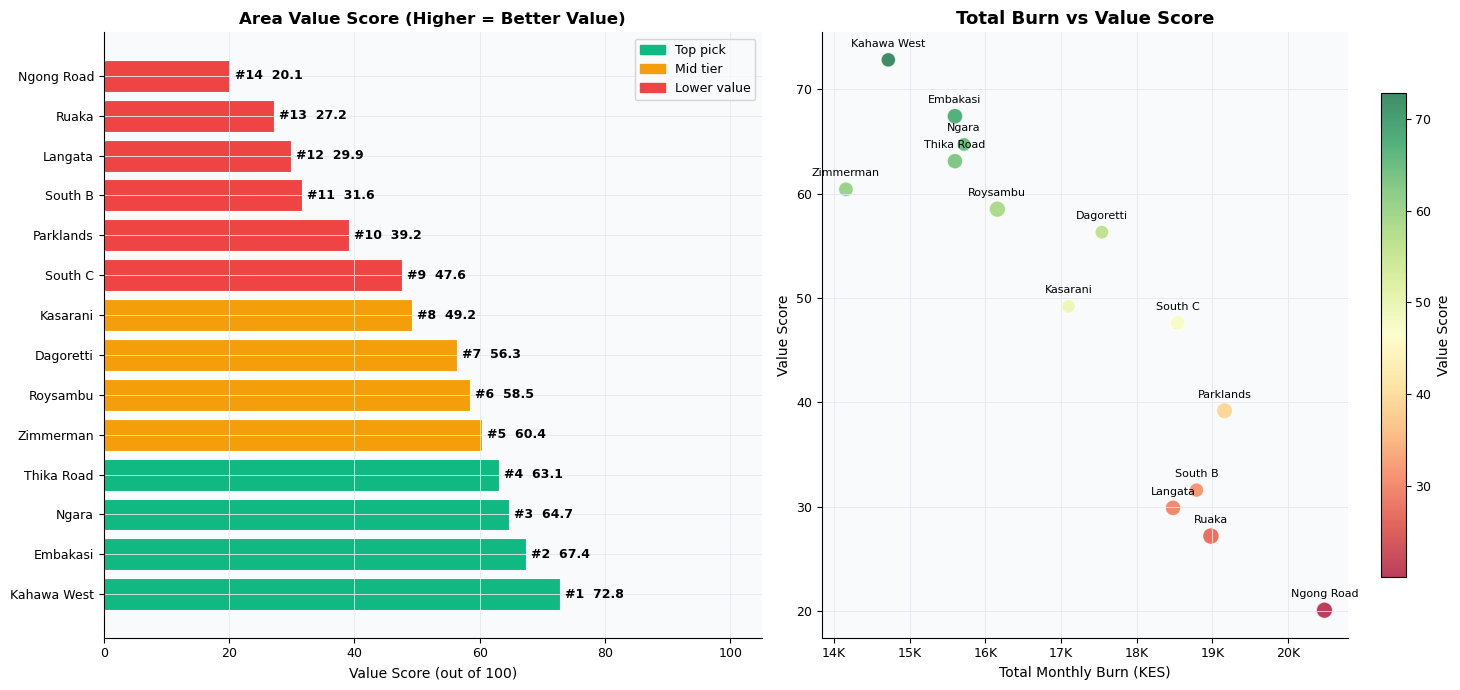


🏆 Top 5 Best-Value Areas for Students:
       area  Score Median Rent Monthly Burn % Private Meter Avg Walk
Kahawa West   72.8   KES 6,500   KES 14,720             64%   22 min
   Embakasi   67.4   KES 6,500   KES 15,600             67%   23 min
      Ngara   64.7   KES 7,500   KES 15,720             59%   19 min
 Thika Road   63.1   KES 6,500   KES 15,600             63%   22 min
  Zimmerman   60.4   KES 5,500   KES 14,160             55%   24 min


In [12]:
# Value score = inverse of total burn, normalised
# + bonus for high % private meters
# + bonus for low average walk time

score_df = (df.groupby('area')
    .agg(
        median_rent     =('rent','median'),
        matatu_monthly  =('matatu_monthly','first'),
        elec_est        =('elec_est','median'),
        pct_private     =('meter', lambda x: (x=='Private').mean()),
        avg_walk        =('walk_min','mean'),
        listings        =('rent','count'),
    )
    .reset_index())

score_df['total_burn'] = (score_df['median_rent'] +
                          score_df['matatu_monthly'] +
                          score_df['elec_est'] + 6300)

# Normalise each component 0–1
def norm(s, invert=False):
    r = (s - s.min()) / (s.max() - s.min())
    return 1 - r if invert else r

score_df['s_cost']    = norm(score_df['total_burn'],  invert=True)  # lower burn = higher score
score_df['s_meter']   = norm(score_df['pct_private'])               # more private = higher score
score_df['s_walk']    = norm(score_df['avg_walk'],    invert=True)  # shorter walk = higher score

# Weighted score: cost 60%, meter 25%, walk 15%
score_df['value_score'] = (score_df['s_cost']  * 0.60 +
                            score_df['s_meter'] * 0.25 +
                            score_df['s_walk']  * 0.15)
score_df['value_score_100'] = (score_df['value_score'] * 100).round(1)
score_df = score_df.sort_values('value_score_100', ascending=False).reset_index(drop=True)

fig, axes = plt.subplots(1, 2, figsize=(15, 7))

# 8a — Horizontal bar chart of value scores
ax = axes[0]
bar_colors = [GREEN if i < 4 else (AMBER if i < 8 else RED) for i in range(len(score_df))]
bars = ax.barh(score_df['area'], score_df['value_score_100'],
               color=bar_colors, edgecolor='white', linewidth=.8)
for bar, val, rank in zip(bars, score_df['value_score_100'], range(1, len(score_df)+1)):
    ax.text(bar.get_width()+0.8, bar.get_y()+bar.get_height()/2,
            f"#{rank}  {val:.1f}", va='center', fontsize=9, fontweight='bold')
ax.set_title('Area Value Score (Higher = Better Value)', fontsize=12)
ax.set_xlabel('Value Score (out of 100)')
ax.set_xlim(0, 105)
patches = [mpatches.Patch(color=GREEN,label='Top pick'),
           mpatches.Patch(color=AMBER,label='Mid tier'),
           mpatches.Patch(color=RED,  label='Lower value')]
ax.legend(handles=patches, fontsize=9)

# 8b — Scatter: total burn vs value score (bubble = listings count)
ax = axes[1]
sc = ax.scatter(score_df['total_burn'], score_df['value_score_100'],
                s=score_df['listings']*2.5, alpha=.75,
                c=score_df['value_score_100'], cmap='RdYlGn', edgecolors='white', linewidth=1)
for _, row in score_df.iterrows():
    ax.annotate(row['area'], (row['total_burn'], row['value_score_100']),
                fontsize=8, ha='center', va='bottom',
                xytext=(0, 8), textcoords='offset points')
plt.colorbar(sc, ax=ax, label='Value Score', shrink=.8)
ax.set_title('Total Burn vs Value Score')
ax.set_xlabel('Total Monthly Burn (KES)')
ax.set_ylabel('Value Score')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x/1000:.0f}K'))

plt.tight_layout()
plt.show()

print("\n🏆 Top 5 Best-Value Areas for Students:")
top5 = score_df.head(5)[['area','value_score_100','median_rent','total_burn','pct_private','avg_walk']]
top5['median_rent'] = top5['median_rent'].map('KES {:,.0f}'.format)
top5['total_burn']  = top5['total_burn'].map('KES {:,.0f}'.format)
top5['pct_private'] = top5['pct_private'].map('{:.0%}'.format)
top5['avg_walk']    = top5['avg_walk'].map('{:.0f} min'.format)
top5 = top5.rename(columns={'value_score_100':'Score','median_rent':'Median Rent',
                              'total_burn':'Monthly Burn','pct_private':'% Private Meter','avg_walk':'Avg Walk'})
print(top5.to_string(index=False))


## 9 · Student Viewing Checklist & Red Flags

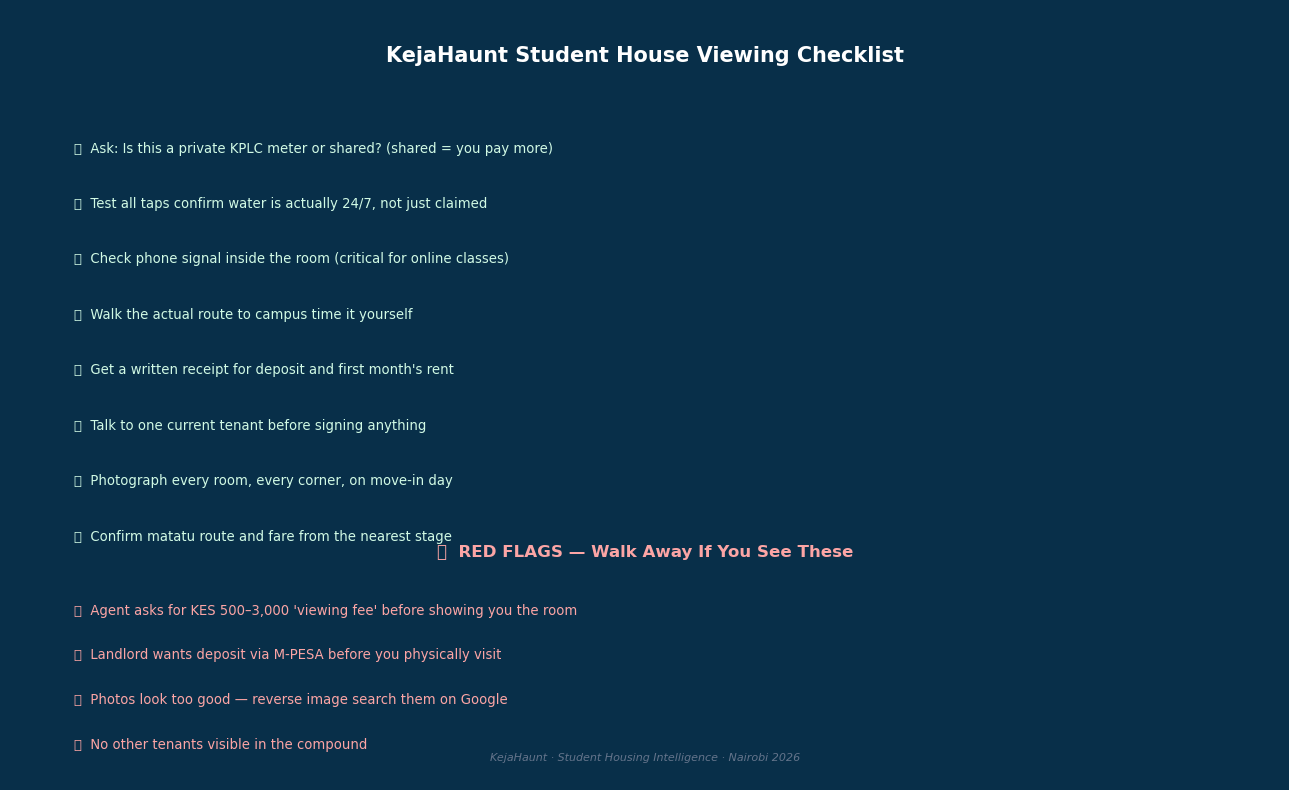

In [15]:
# Summary visualisation — checklist card
fig, ax = plt.subplots(figsize=(13, 8))
ax.set_xlim(0, 10); ax.set_ylim(0, 10)
ax.axis('off')
fig.patch.set_facecolor('#082f49')

# Title
ax.text(5, 9.4, 'KejaHaunt Student House Viewing Checklist',
        ha='center', va='center', fontsize=15, fontweight='bold', color='white')

# Green checks
checks = [
    "✅  Ask: Is this a private KPLC meter or shared? (shared = you pay more)",
    "✅  Test all taps confirm water is actually 24/7, not just claimed",
    "✅  Check phone signal inside the room (critical for online classes)",
    "✅  Walk the actual route to campus time it yourself",
    "✅  Get a written receipt for deposit and first month's rent",
    "✅  Talk to one current tenant before signing anything",
    "✅  Photograph every room, every corner, on move-in day",
    "✅  Confirm matatu route and fare from the nearest stage",
]
for i, c in enumerate(checks):
    ax.text(0.5, 8.2 - i*0.72, c, fontsize=9.5, color='#d1fae5', va='center')

# Red flags
ax.text(5, 2.9, '🚨  RED FLAGS — Walk Away If You See These',
        ha='center', fontsize=12, fontweight='bold', color='#fca5a5')
reds = [
    "🔴  Agent asks for KES 500–3,000 'viewing fee' before showing you the room",
    "🔴  Landlord wants deposit via M-PESA before you physically visit",
    "🔴  Photos look too good — reverse image search them on Google",
    "🔴  No other tenants visible in the compound",
]
for i, r in enumerate(reds):
    ax.text(0.5, 2.2 - i*0.58, r, fontsize=9.5, color='#fca5a5', va='center')

ax.text(5, 0.25, 'KejaHaunt · Student Housing Intelligence · Nairobi 2026',
        ha='center', fontsize=8, color='#64748b', style='italic')

plt.tight_layout()
plt.show()


## 10 · Key Findings & Recommendations

---

### 🏆 Best Value Areas (2026)

| Rank | Area | Why |
|------|------|-----|
| 1 | **Zimmerman** | Cheapest median rent (KES 5,500), near KU, strong comrade community |
| 2 | **Kahawa West** | KES 6,500 median, closest to KU and MKU gates, high % private meters |
| 3 | **Embakasi** | KES 6,000 median, serves KCA, good Airport Road matatu links |
| 4 | **Ngara** | KES 7,000, shortest matatu fare (KES 30) to UoN and TUK |
| 5 | **Roysambu** | KES 7,500, Thika Superhighway BRT, serves USIU and KU |

---

### 💡 Top Insights

**1. The KPLC Meter is a Hidden Tax**  
A shared meter costs ~KES 600 extra per month vs a private one. Over a 4-year degree that is **KES 28,800 wasted**. Always ask before signing.

**2. Proximity Premium is Real**  
Every 10 minutes closer to campus adds ~KES 700 to monthly rent. Factor in transport savings — a room KES 2,000 cheaper that costs KES 1,500 more in matatu per month is not a saving.

**3. Total Burn vs Headline Rent**  
A bedsitter at KES 7,000 in Roysambu (KES 880 matatu) has the same total burn as a KES 8,500 room in Ngara (KES 660 matatu). Always calculate total burn, not just rent.

**4. Satellite Towns Offer Best Value**  
Zimmerman, Kahawa West and Embakasi consistently outperform inner zones on value score — cheaper rent, decent matatu links, and growing amenity base.

---

### 📋 Budget Guide for Students

| Monthly Allowance | Recommended Zones | Max Rent to Stay Comfortable |
|------------------|--------------------|------------------------------|
| KES 10,000 | Zimmerman, Kahawa West, Embakasi | KES 4,000–5,000 |
| KES 15,000 | Ngara, Roysambu, Thika Road | KES 6,000–7,500 |
| KES 20,000 | Kasarani, South B, Dagoretti | KES 8,000–10,000 |
| KES 25,000+ | Parklands, Ngong Road, South C | KES 10,000–13,000 |

---

*Data is synthetic but calibrated to 2025/26 Nairobi market conditions. For live listings, visit KejaHaunt.*
